|<img style="float:left;" src="images/usherb_transp.gif"> |Pierre Proulx, ing, professeur|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|

### Section 10-5

> Voici un problème qui devient très complexe à traiter __à la main__ et ou l'utilisation de calculateur formel de type **sympy, mathematica/wolfram, maple, mupad, maxima, mathcad ** ou tout autre calculateur symbolique devient très utile. Ainsi dans le document qui suit, seulement la pose du problème est nécessaire, tout le travail mathématique est fait par **sympy**.  

>Le réacteur catalytique a 3 sections, seule la section du milieu a une source thermique


><img src='images/Chap-10-Section-10-5-1.png' width=400 height=400>


>les équations de bilans donnent:
<img src='images/Chap-10-Section-10-5-2.png' width=500 height=500>

>Dans le livre de Transport Phenomena, Bird utilise un artifice afin de solutionner plus facilement, il considère que la conduction axiale est négligeable (c'est le terme contenant la conductivité thermique). Dans ce qui suit, nous ne ferons pas cette hypothèse, ** SYMPY ** nous aide à solutionner et les manipulations algébriques sont faites automatiquement. Nous modifierons aussi les conditions de géométrie légèrement (on ne considèrera pas z=-infini à l'entrée, mais z=0). On n'utilisera pas des variables adimensionelles mais z=0, z=1 et z=3 comme dimensions du réacteur. La solution sera ainsi un peu différente de celle du livre. Le tracage des courbes nous confirmera que la solution est bien similaire, et bien plus réaliste!

In [1]:
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline
import matplotlib.pyplot as plt
from ipywidgets import *

In [2]:
# Paramètres, variables et fonctions, on utilise directement les équations définies
# plus haut
rho,v,c_p,k,S,z=sp.symbols('rho,v,c_p,k,S,z')                                                            
T_1=sp.Function('T_1')(z)
T_2=sp.Function('T_2')(z)
T_3=sp.Function('T_3')(z)
eq1=sp.Eq(k*sp.diff(T_1,z,z),rho*v*c_p*sp.diff(T_1,z))
eq2=sp.Eq(k*sp.diff(T_2,z,z),rho*v*c_p*sp.diff(T_2,z)+S)
eq3=sp.Eq(k*sp.diff(T_3,z,z),rho*v*c_p*sp.diff(T_3,z))
T_1=sp.dsolve(eq1,T_1)
T_2=sp.dsolve(eq2,T_2)  
T_3=sp.dsolve(eq3,T_3)
display(T_1,T_2,T_3)
#
# Renommer les constantes C1 et C2 dans les équations 2 et 3
#
T_1=T_1.rhs
T_2=T_2.subs(sp.symbols('C1'),sp.symbols('C3'))
T_2=T_2.subs(sp.symbols('C2'),sp.symbols('C4')).rhs
T_3=T_3.subs(sp.symbols('C1'),sp.symbols('C5'))
T_3=T_3.subs(sp.symbols('C2'),sp.symbols('C6')).rhs
display(T_1,T_2,T_3)


In [3]:
#
# On peut calculer les flux de Fourier à partir des températures obtenues
#
q_1 =-k*sp.diff(T_1,z)
q_2 =-k*sp.diff(T_2,z)
q_3 =-k*sp.diff(T_3,z)

In [4]:
# écrivons les équations de base qui seront utilisées, au besoin
display(T_1)
display(T_2)
display(T_3)
display(q_1)
display(q_2)
display(q_3)

In [5]:
# Les conditions aux limites, 6 équations 6 inconnues.#
# Regardez bien ci-haut, on doit prendre la partie de droite des équations!!!
T_0,z_1,z_2=sp.symbols('T_0,z_1,z_2')
condition_1=T_1.subs(z,0)-T_0                   # T_1(0)=T_0
condition_2=T_1.subs(z,z_1)-T_2.subs(z,z_1)     # T_1(z1) = T_2(z1)
condition_3=q_1.subs(z,z_1)-q_2.subs(z,z_1)     # q_1(z1) = q_2(z1)
condition_4=T_2.subs(z,z_2)-T_3.subs(z,z_2)     # T_2(z2) = T_3(z2)
condition_5=q_2.subs(z,z_2)-q_3.subs(z,z_2)     # q_2(z2) = q_2(z2)
condition_6=q_3.subs((z,sp.oo),0)               # q_3(inf) = 0

In [6]:
display(condition_1)
display(condition_2)
display(condition_3)   
display(condition_4)
display(condition_5)
display(condition_6)

In [7]:
# Ici on résoud le problème des 6 conditions aux limites pour trouver les 6 constantes
conditions=[condition_1,condition_2,condition_3,condition_4,condition_5,condition_6]
constantes=sp.solve(conditions,sp.symbols('C1,C2,C3,C4,C5,C6'))
#display('Les constantes C1 à C6 sont obtenues facilement, même si elles sont très lourdes',constantes)
# Voila le travail.

'Les solutions complètes de T1, T2, T3, q1, q2 et q3 sont obtenues en substituant les constantes'

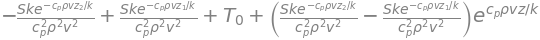

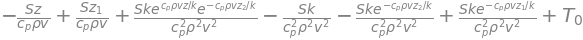

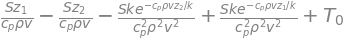

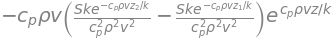

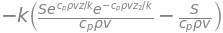

In [8]:
T_1=T_1.subs(constantes)
T_2=T_2.subs(constantes)
T_3=T_3.subs(constantes)
q_1=q_1.subs(constantes)
q_2=q_2.subs(constantes)
q_3=q_3.subs(constantes)
display('Les solutions complètes de T1, T2, T3, q1, q2 et q3 sont obtenues en substituant les constantes')
display(T_1)
display(T_2)
display(T_3)
display(q_1)
display(q_2)
display(q_3)

>> On peut encore une fois essayer de tracer ces profils en substituant des valeurs pour les paramètres. Le profil dans la section 3 doit être plat car il n'y a pas de flux, la température sera une constante. Dans la section 10-5, Bird néglige le terme de conduction de la chaleur, ce qui donne donne les résultats suivants:

<img src='images/Chap-10-Section-10-5-3.png' width=400 height=400>

>> Vous pouvez constater que les profils de température sont un peu étranges car la température change brusquement, cette cassure dans le profil thermique n'est pas complètement réaliste. Les graphes qu'on obtient en tenant compte de la conduction thermique sont plus réalistes, voyez ci-bas.

In [11]:
def f(source,Vitesse,longueur):
    ### Les valeurs utilisées sont en S.I., pas de cm, calories, et autres unités toxiques
    dico={'c_p':800,'z_1':longueur*0.4,'z_2':longueur*0.8,'k':2,'T_0':450,'rho':1}
    T_1plot=T_1.subs(dico).subs(S,source).subs(v,Vitesse)
    T_2plot=T_2.subs(dico).subs(S,source).subs(v,Vitesse)
    T_3plot=T_3.subs(dico).subs(S,source).subs(v,Vitesse)
    plt.rcParams['figure.figsize'] = 8,5
    V1=sp.Function('V1')(z)
    V2=sp.Function('V2')(z)
    p=sp.plot((T_1plot,(z,0,z_1.subs(dico))),\
              (T_2plot,(z,z_1.subs(dico),z_2.subs(dico))),\
              (T_3plot,(z,z_2.subs(dico),longueur)),
        show=False,legend=True,ylabel='T [K]',xlabel='z [m]')
    p[0].label='inerte                                           '
    p[1].label='réaction Source='+str(source)[0:5]+', rho v ='+str(Vitesse)+'                                          '
    p[2].label='inerte                                           '
    p[0].line_color='blue'
    p[1].line_color='cyan'
    p[2].line_color='red'
    if source<0:
        p.title='Profil de température réaction exothermique'
    else:
        p.title='Profil de température réaction endothermique'
    p.show()
    return
g=interactive(f,source=(-1000001,200001,1000),Vitesse=(0.1,2,0.1),\
             longueur=(0.01,0.5,0.01))

In [12]:
display(g)

interactive(children=(IntSlider(value=-400001, description='source', max=200001, min=-1000001, step=1000), Flo…